## Time to get you hands dirty!  Position of a star

*(exam guidelines available [here](https://github.com/dgerosa/astrostatistics_bicocca_2026/blob/main/exams.md))*

You measure the position of a star $N$ times with the *same* telescope i.e. errors are homoscedastic. Let's say the underlying process is Gaussian, the true position is $\mu = 1$ (in suitable units), and the erorrs are $\sigma=0.2$

### Part 1

- Generate fake measurements. Treat each of these observations as an estimate of the true distribution. So we'll center a Gaussian (with the known $\sigma$) at each point. This is the probability of each data point, $p(x_i|\mu,\sigma)$.
- Plot each of the individual likelihoods separately.  Also plot their product (i.e. the likelihood of the dataset $\{x_i\}$). Make sure the x grid has enough points.
- Just read off the maximum likelihood solution (e.g. using `np.argsort`) 
- Compare it with the MLE estimator derived above


In [1]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

In [2]:
sigma = 0.2
N = 50
x = scipy.stats.norm(1,sigma).rvs(N)

In [3]:
M = 1000
prod = np.ones(M)
x_grid = np.linspace(0,2,M)
for i,loc in enumerate(x_grid):
    g = scipy.stats.norm(loc, sigma)
    gauss = g.pdf(x)
    #plt.scatter(x, gauss)
    prod[i] = np.prod(gauss) # computing the product of the likelihood of each x point being drawn from the gaussian centered at loc
                            # the likelihood of x coincides with the gaussian pdf computed in x

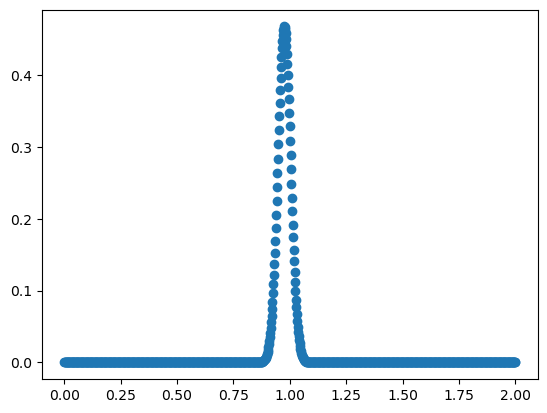

In [4]:
plt.scatter(x_grid, prod)

In [5]:
print('Maximum of the likelihood:', x_grid[np.argmax(prod)])
print('Mean of the sample:', np.mean(x))

Maximum of the likelihood: 0.974974974974975
Mean of the sample: 0.9752390506432068



### Part 2

Check the Fisher matrix error estimate makes sense
- do a rough $2^\mathrm{nd}$ order differentation of our log-likelihood function with `np.diff`, 
- divide through by our $\Delta \theta^2$ to get the correct normalization, 
- multiply by $-1$, 
- then take the square root.
- Compare with the Fisher matrix error derived above
- Plot a Gaussian at the measured $\mu$ with this error as the scale to see if it matches the numerical likelihood distribution. (The normalization won't be captured, you can rescale it as you like to check it agrees) 


In [6]:
print('spread of likelihood:',np.std(prod))

spread of likelihood: 0.0721342721144776


In [ ]:
log_like = np.log(prod) # diff has steps of width 1 so I need to correct
fish_err = (np.diff(log_like, 2)/((x_grid[1]-x_grid[0])**2))[np.argmax(prod)]
fish_err = np.sqrt(-fish_err)

In [11]:
print(fish_err)

35.35533905930637


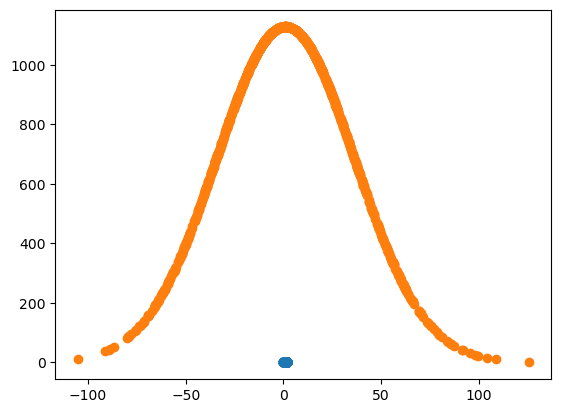

In [12]:
gaussian = scipy.stats.norm(x_grid[np.argmax(prod)],fish_err)
x = gaussian.rvs(1000)
plt.scatter(x_grid, prod)
plt.scatter(x, gaussian.pdf(x)*1e5)


### Part 3

Let's make our model more realistic. Our $N$ measurements were taken in different nights, where the sky behaved differently (i.e. errors are heteoscedastic). Let's assume that each measurment has a $\sigma_i$ that is normally distributed with mean $0.2$ and standard deviation $0.05$

- Generalize your code from above to this case

In [ ]:
N = 1000
x = scipy.stats.norm(1,0.2).rvs(N)
sigma = scipy.stats.norm(0.2,0.05).rvs(N)

In [ ]:
prod = np.ones(N)
x_grid = np.linspace(0,2,N)
for i,(loc, s) in enumerate(zip(x_grid, sigma)):
    g = scipy.stats.norm(loc, s)
    gauss = g.pdf(x)
    #plt.scatter(x, gauss)
    prod[i] = np.prod(gauss) # computing the product of the likelihood of each x point being drawn from the gaussian centered at loc
                            # the likelihood of x coincides with the gaussian pdf computed in x

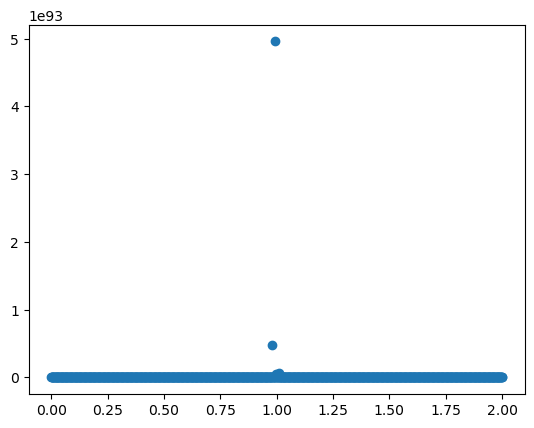

In [ ]:
plt.scatter(x_grid, prod)

In [ ]:
print('Maximum of the likelihood:', x_grid[np.argmax(prod)])
print('Mean of the sample:', np.mean(x))

Maximum of the likelihood: 0.992992992992993
Mean of the sample: 0.9930356168317162


In [ ]:
# MLE per sigma

N = 50
M = 1000
x = scipy.stats.norm(1,0.2).rvs(M)

prod = np.ones([N,N])
x_grid = np.linspace(0,2,N)
sigma_grid = np.linspace(0.05, 0.35, N)

for i,loc in enumerate(x_grid):
    for j,s in enumerate(sigma_grid):
        g = scipy.stats.norm(loc, s)
        gauss = g.pdf(x)
        #plt.scatter(x, gauss)
        prod[i][j] = np.prod(gauss) # computing the product of the likelihood of each x point being drawn from the gaussian centered at loc
                                # the likelihood of x coincides with the gaussian pdf computed in x


In [ ]:
np.floor(np.argmax(prod)%N)

np.int64(25)

In [ ]:
print('Maximum of the likelihood for mu:', x_grid[np.argmax(prod)%N])
print('Maximum of the likelihood for sigma:', sigma_grid[int(np.floor(np.argmax(prod)/N))])
print('Mean of the sample:', np.mean(x))

Maximum of the likelihood for mu: 1.0204081632653061
Maximum of the likelihood for sigma: 0.19693877551020406
Mean of the sample: 0.9915417654733827
